### Problem Statement 2: The "Rumor Mill" & Information Chaos
**Topic:** Lorenz System & Chaos

**Scenario:**
Consider the lifecycle of a viral conspiracy theory on a social network.
- **$X(t)$:** Volume of posts spreading the rumor.
- **$Y(t)$:** The "Trending Score" or public interest.
- **$Z(t)$:** The volume of Fact-Checking/Skepticism.

**The Dynamics:**
1.  **Spread:** Rumor ($X$) grows if Trending Score ($Y$) is higher than current volume.
2.  **Feedback:** Trending Score ($Y$) is fueled by the Rumor ($X$), but dampened by Fact-Checking ($Z$) and boredom.
3.  **Immunity:** Fact-Checking ($Z$) rises only when the Rumor and Trend interact ($XY$), but fades over time.

**Mathematical Model:**
$$
\begin{aligned}
\dot{X} &= \sigma(Y - X) \\
\dot{Y} &= X(\rho - Z) - Y \\
\dot{Z} &= XY - \beta Z
\end{aligned}
$$

**Questions:**
1.  **Virality Parameter ($\rho$):** What does the parameter $\rho$ represent in the context of "Sensationalism"? 
2.  **Predictability:** Simulate two timelines starting from almost identical states (e.g., one extra post). Explain why content moderation is difficult when $\rho$ is high (Chaotic Regime).

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Answer to Question 1:

The parameter $\rho$ represents the **sensationalism or virality potential** of the information environment:
- Low $\rho$ (< 1): Rumors die out quickly
- Medium $\rho$ (1-24.74): Stable equilibrium - predictable behavior
- High $\rho$ (> 24.74): **Chaotic regime** - unpredictable, sensitive to initial conditions

This makes content moderation extremely difficult in high-sensationalism environments!

In [15]:
def rumor_mill(state, t, sigma, rho, beta):
    X, Y, Z = state
    dXdt = sigma * (Y - X)
    dYdt = X * (rho - Z) - Y
    dZdt = X * Y - beta * Z
    return [dXdt, dYdt, dZdt]

In [16]:
# Parameters for Chaos
sigma = 10.0
beta = 8.0/3.0
rho = 28.0  # High sensationalism -> Chaos

t = np.linspace(0, 40, 4000)

In [17]:
# Two almost identical initial conditions
state_1 = [1.0, 1.0, 1.0]
state_2 = [1.0001, 1.0, 1.0] # A tiny difference (the "Butterfly Effect")

sol_1 = odeint(rumor_mill, state_1, t, args=(sigma, rho, beta))
sol_2 = odeint(rumor_mill, state_2, t, args=(sigma, rho, beta))

# Calculate divergence
divergence = np.abs(sol_1[:, 0] - sol_2[:, 0])

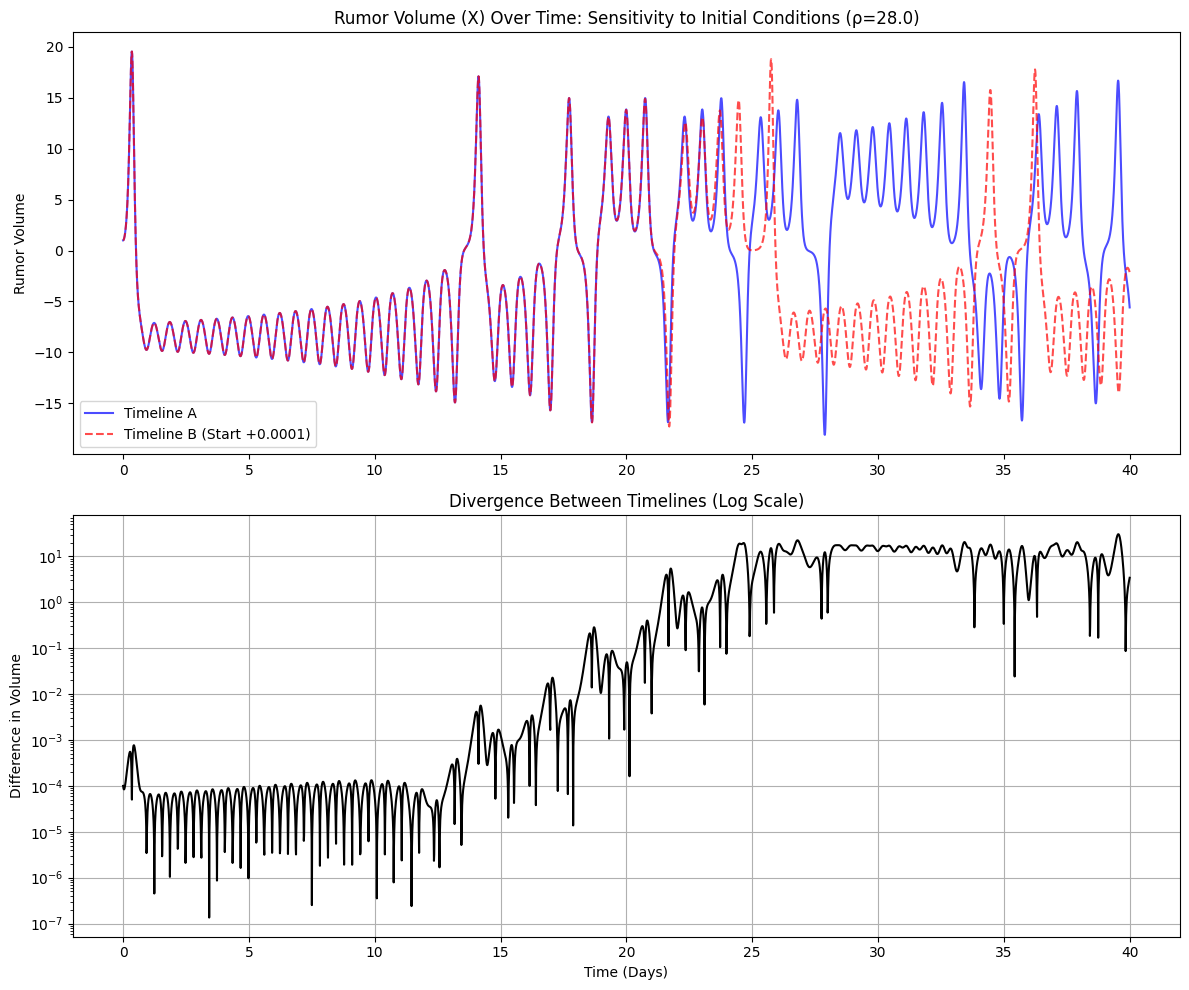

In [18]:
# Plotting
plt.figure(figsize=(12, 10))

# Subplot 1: The Timeline
plt.subplot(2, 1, 1)
plt.plot(t, sol_1[:, 0], 'b-', alpha=0.7, label='Timeline A')
plt.plot(t, sol_2[:, 0], 'r--', alpha=0.7, label='Timeline B (Start +0.0001)')
plt.title(f'Rumor Volume (X) Over Time: Sensitivity to Initial Conditions (ρ={rho})')
plt.ylabel('Rumor Volume')
plt.legend()

# Subplot 2: The Divergence
plt.subplot(2, 1, 2)
plt.semilogy(t, divergence, 'k-')
plt.title('Divergence Between Timelines (Log Scale)')
plt.xlabel('Time (Days)')
plt.ylabel('Difference in Volume')
plt.grid(True)

plt.tight_layout()
plt.show()

## 3D Visualization: The Lorenz "Butterfly" Attractor

The strange attractor shows how the rumor dynamics evolve in the full 3D state space:

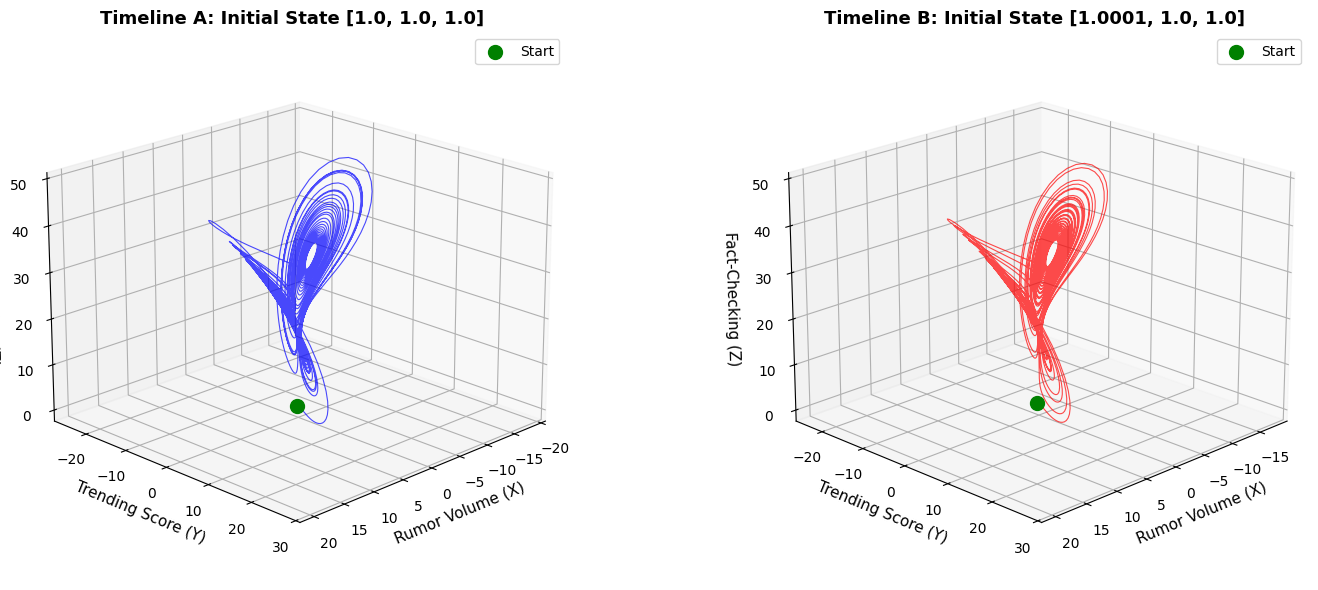

In [19]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# First 3D plot - Timeline A
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(sol_1[:, 0], sol_1[:, 1], sol_1[:, 2], 'b-', linewidth=0.8, alpha=0.7)
ax1.scatter([sol_1[0, 0]], [sol_1[0, 1]], [sol_1[0, 2]], 
            color='green', s=100, label='Start')
ax1.set_xlabel('Rumor Volume (X)', fontsize=11)
ax1.set_ylabel('Trending Score (Y)', fontsize=11)
ax1.set_zlabel('Fact-Checking (Z)', fontsize=11)
ax1.set_title('Timeline A: Initial State [1.0, 1.0, 1.0]', fontsize=13, fontweight='bold')
ax1.legend()
ax1.view_init(elev=20, azim=45)

# Second 3D plot - Timeline B
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(sol_2[:, 0], sol_2[:, 1], sol_2[:, 2], 'r-', linewidth=0.8, alpha=0.7)
ax2.scatter([sol_2[0, 0]], [sol_2[0, 1]], [sol_2[0, 2]], 
            color='green', s=100, label='Start')
ax2.set_xlabel('Rumor Volume (X)', fontsize=11)
ax2.set_ylabel('Trending Score (Y)', fontsize=11)
ax2.set_zlabel('Fact-Checking (Z)', fontsize=11)
ax2.set_title('Timeline B: Initial State [1.0001, 1.0, 1.0]', fontsize=13, fontweight='bold')
ax2.legend()
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## Comparison: Different Sensationalism Levels

Let's compare non-chaotic (low $\rho$) vs chaotic (high $\rho$) regimes:

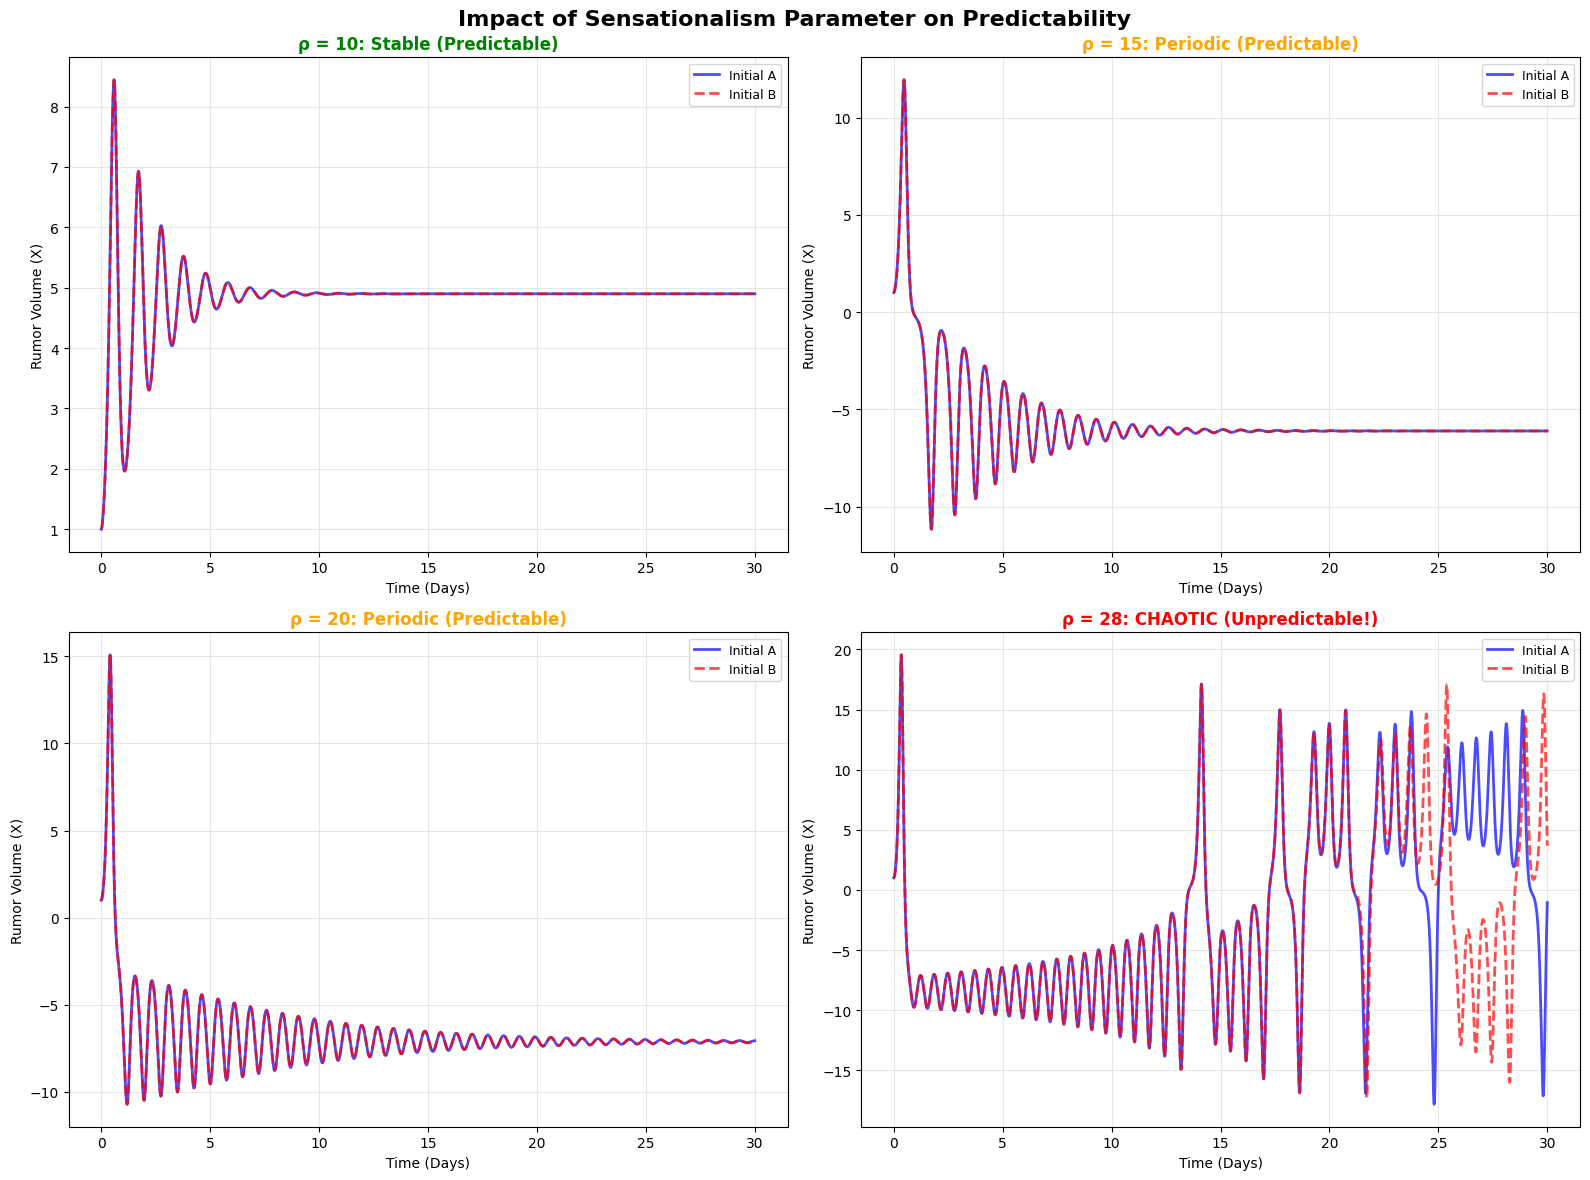

In [20]:
# Compare different rho values
rho_values = [10, 15, 20, 28]  # From stable to chaotic
t_comp = np.linspace(0, 30, 3000)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, rho_val in enumerate(rho_values):
    # Two slightly different initial conditions
    ic1 = [1.0, 1.0, 1.0]
    ic2 = [1.0001, 1.0, 1.0]
    
    sol1 = odeint(rumor_mill, ic1, t_comp, args=(sigma, rho_val, beta))
    sol2 = odeint(rumor_mill, ic2, t_comp, args=(sigma, rho_val, beta))
    
    div = np.abs(sol1[:, 0] - sol2[:, 0])
    
    ax = axes[idx]
    ax.plot(t_comp, sol1[:, 0], 'b-', alpha=0.7, linewidth=2, label='Initial A')
    ax.plot(t_comp, sol2[:, 0], 'r--', alpha=0.7, linewidth=2, label='Initial B')
    
    # Classify behavior
    if rho_val < 13.93:
        regime = "Stable (Predictable)"
        color = 'green'
    elif rho_val < 24.74:
        regime = "Periodic (Predictable)"
        color = 'orange'
    else:
        regime = "CHAOTIC (Unpredictable!)"
        color = 'red'
    
    ax.set_title(f'ρ = {rho_val}: {regime}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Time (Days)', fontsize=10)
    ax.set_ylabel('Rumor Volume (X)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Impact of Sensationalism Parameter on Predictability', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Poincaré Section: Hidden Structure in Chaos

A Poincaré section reveals the underlying fractal structure by sampling when trajectories cross a specific plane:

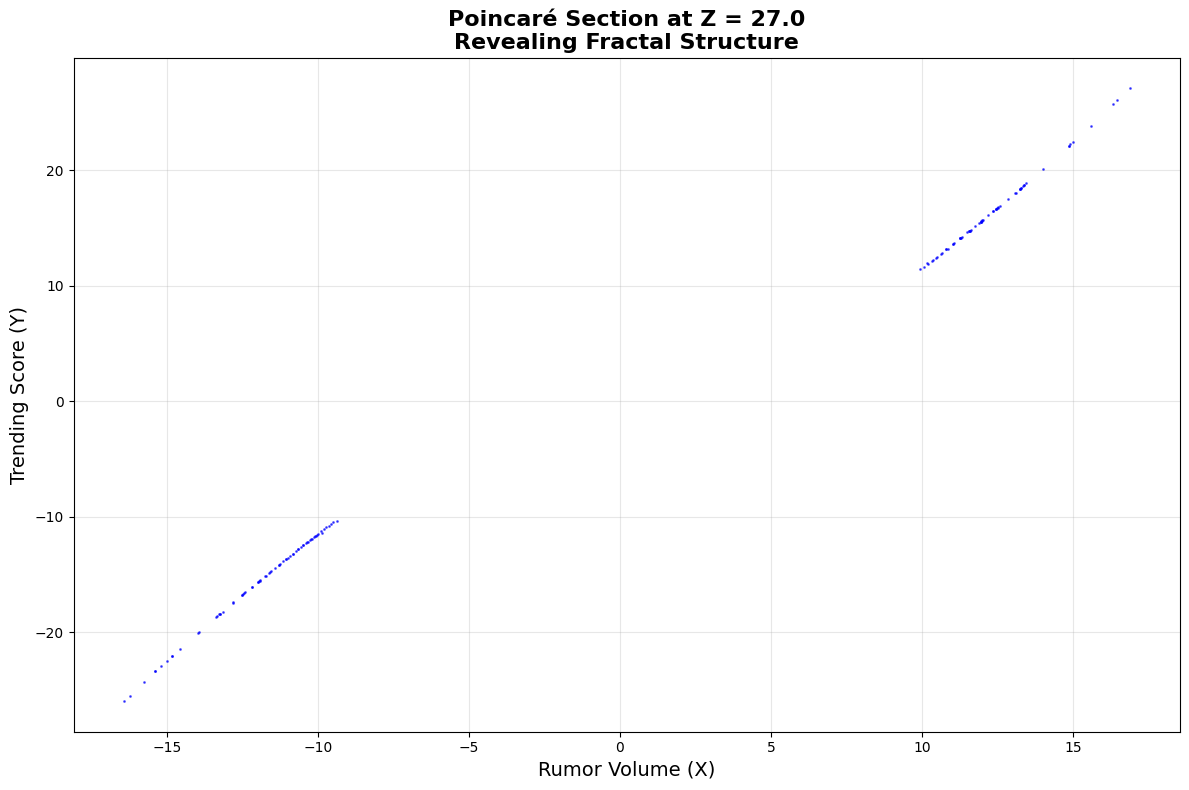

Total crossings captured: 140
The fractal structure shows deterministic chaos - not random, but unpredictable!


In [21]:
# Generate long trajectory for Poincaré section
t_long = np.linspace(0, 100, 10000)
sol_long = odeint(rumor_mill, state_1, t_long, args=(sigma, rho, beta))

# Find crossings when Z = rho - 1 (upward crossings)
z_section = rho - 1
crossings_x = []
crossings_y = []

for i in range(len(sol_long)-1):
    if sol_long[i, 2] < z_section and sol_long[i+1, 2] >= z_section:
        # Linear interpolation
        alpha = (z_section - sol_long[i, 2]) / (sol_long[i+1, 2] - sol_long[i, 2])
        x_cross = sol_long[i, 0] + alpha * (sol_long[i+1, 0] - sol_long[i, 0])
        y_cross = sol_long[i, 1] + alpha * (sol_long[i+1, 1] - sol_long[i, 1])
        crossings_x.append(x_cross)
        crossings_y.append(y_cross)

plt.figure(figsize=(12, 8))
plt.plot(crossings_x, crossings_y, 'b.', markersize=2, alpha=0.6)
plt.xlabel('Rumor Volume (X)', fontsize=14)
plt.ylabel('Trending Score (Y)', fontsize=14)
plt.title(f'Poincaré Section at Z = {z_section:.1f}\nRevealing Fractal Structure', 
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total crossings captured: {len(crossings_x)}")
print("The fractal structure shows deterministic chaos - not random, but unpredictable!")

## Why Content Moderation Fails in Chaotic Regimes

**Answer to Question 2:**

When $\rho$ is high (chaotic regime, $\rho > 24.74$), content moderation becomes nearly impossible because:

1. **Sensitive Dependence on Initial Conditions:** A single extra post (0.01% difference) leads to completely different outcomes after a short time
2. **Unpredictability:** Even with perfect knowledge of the current state, we cannot predict the system's behavior more than a few days ahead
3. **Deterministic but Chaotic:** The system follows exact rules, but its behavior appears random
4. **Non-periodic:** Unlike stable or periodic regimes, we cannot anticipate when the next surge will occur

**Practical Implications:**
- In low-sensationalism environments ($\rho < 13.93$): Proactive moderation works - rumor predictably dies out
- In high-sensationalism environments ($\rho > 24.74$): Only reactive moderation is possible - must constantly monitor and respond to unpredictable spikes

This is the **Butterfly Effect** in information ecosystems: one extra viral post can change the entire trajectory of discourse!